# CDS prediction overlap across models

Compares raw predictions between models directly - which CDS calls are made by every
model, which are unique to one model, which are shared by some subset - with **no
reference to ground truth**. Two predicted CDS (from different models, same read) are
considered "the same" call if their IoU meets `overlap_criteria`; overlapping calls are
chained together (transitively) across models via union-find, and each resulting cluster
is tallied by exactly which set of models contributed a call to it.

In [1]:
import glob
import os
import pickle
import sys

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = False
import numpy as np
from tqdm import tqdm

sys.path.insert(0, '..')
from plot_config import MODEL_DISPLAY_NAMES, FONT_SIZES

plt.rcParams.update(FONT_SIZES)

In [2]:
# SCARB cluster data root - matches the project_root convention used by
# postprocess_metagenome_testset.py / postprocess_metagenome/*.py, since that's
# where all of this notebook's inputs actually live on this machine.
project_root = "/tmp/nrt204/FragmentPredictor"

data_dir = "CAMI_metagenome"  # matches predict_metagenome/ and postprocess_metagenome/ convention

# When True, compare predictions with reads overlapping a hypothetical-protein /
# ab-initio-prediction-tagged CDS removed entirely - see postprocess_metagenome/*.py's
# EXCLUDE_UNCERTAIN_REGION_READS toggle of the same name. Requires having already run
# those scripts with that toggle on; raises FileNotFoundError below otherwise. No ground
# truth is used in this notebook either way - this only changes which reads' predictions
# are considered, to stay consistent with whichever test-set variant you're comparing to
# elsewhere.
EXCLUDE_UNCERTAIN_REGION_READS = False

# processed_predictions/ is written under this directory name by the postprocessing
# scripts (see their EXCLUDE_UNCERTAIN_REGION_READS toggle).
eval_data_dir = data_dir + ("_no_ab_initio" if EXCLUDE_UNCERTAIN_REGION_READS else "")

# Minimum IoU for two different models' predicted CDS on the same read to count as
# "the same" call. Lower than the ground-truth matching threshold (0.8) might be more
# appropriate here since different tools can disagree on exact start/stop even when
# they agree a gene is there - tune as needed.
overlap_criteria = 1

# One representative variant per tool by default (DeepCDS S, the substitution-errors
# variant, and FGS Complete) so the headline comparison is a clean 3-way "one call per
# tool" picture - add fgs_illumina_5/10 or deep_cds_no_errors/errors here for a finer
# comparison. (deep_cds_no_errors ("N") is still running for CAMI as of this writing -
# its processed predictions only cover a partial snapshot of the data.)
models_to_compare = ["prodigal", "fgs_complete", "deep_cds_no_errors"]

# Load data if already processed; set to False to re-run data processing and overwrite cached results
LOAD_PROCESSED_DATA = False

In [3]:
# Sample discovery uses raw reads_processed/ (data_dir, not eval_data_dir) since this
# notebook only needs predictions, not the test set - reads_processed/ is never filtered
# by the ab-initio-exclusion toggle.
input_dir = f"{project_root}/data/processed_data/reads_processed/test/{data_dir}"
samples = sorted(
    os.path.basename(p).replace("_cds_labels.tsv.gz", "")
    for p in glob.glob(f"{input_dir}/*_cds_labels.tsv.gz")
)
if not samples:
    raise FileNotFoundError(f"No *_cds_labels.tsv.gz files found in: {input_dir}")
print(f"CAMI samples: {samples}")
print(f"Comparing models: {models_to_compare}")

_script_name = "cds_prediction_overlap_across_models"
_models_key = "-".join(models_to_compare)
_cache_dir = f"{project_root}/data/processed_data/report_results/{eval_data_dir}/{_script_name}/oc_{overlap_criteria}/{_models_key}"

CAMI samples: ['sample_0']
Comparing models: ['prodigal', 'fgs_complete', 'deep_cds_no_errors']


In [4]:
def get_full_cds(reads_dict):
    """Merge fragmented CDS annotations that belong to the same gene.

    When a CDS is split into multiple fragments (e.g. due to short fragment
    removal during preprocessing), this function reconnects them into a single
    CDS span using the cds_fragments_connection mapping. The merged CDS is
    labelled 'disrupted_rf' and replaces the individual fragments.

    The original per-fragment coordinates (each with its own RF label) are
    preserved as a 4th element so that calculate_iou can determine which
    positions within the disrupted span belong to which reading frame:
        [start, end, 'disrupted_rf', [(s1, e1, rf1), (s2, e2, rf2), ...]]

    Args:
        reads_dict: Dict mapping read names to dicts with 'cds_coords' (list of
            [start, end, rf] triplets) and 'cds_fragments_connection' (list of
            index groups indicating which fragments belong together).

    Returns:
        The modified reads_dict with fragmented CDS entries merged.
    """
    for read in reads_dict.keys():
        cds_fragments_connections = reads_dict[read]['cds_fragments_connection']
        cds_coords = reads_dict[read]['cds_coords']

        indices_to_remove = []

        for cds_frag_mapping in cds_fragments_connections:
            if len(cds_frag_mapping) > 1:
                # Postprocessing for testset due to how short fragments were removed
                if len(cds_fragments_connections) != cds_frag_mapping[0] + 1:
                    if len(cds_frag_mapping) == 1:
                        cds_frag_mapping = [cds_index - 1 for cds_index in cds_frag_mapping]

                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [0, 2]:
                    cds_frag_mapping = [0, 1]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [2, 3, 4]:
                    cds_frag_mapping = [0, 1, 2]

                start_cds_frag = cds_coords[min(cds_frag_mapping)][0]
                end_cds_frag = cds_coords[max(cds_frag_mapping)][1]

                # Preserve individual fragment coordinates sorted by start position.
                fragment_list = sorted(
                    [(cds_coords[i][0], cds_coords[i][1], cds_coords[i][2])
                     for i in cds_frag_mapping],
                    key=lambda f: f[0]
                )

                indices_to_remove += cds_frag_mapping

                assert start_cds_frag < end_cds_frag, "Something went wrong processing indel-induced error in sequence!"
                cds_coords.append([start_cds_frag, end_cds_frag, 'disrupted_rf', fragment_list])
                reads_dict[read]['cds_coords'] = cds_coords

        for index in sorted(indices_to_remove, reverse=True):
            cds_coords.pop(index)

    return reads_dict


def _get_rf_spans(coord):
    """Extract per-RF coordinate spans from a CDS coord entry.

    Args:
        coord: [start, end, rf] or [start, end, 'disrupted_rf', [(s,e,rf), ...]].

    Returns:
        Dict mapping rf_label -> list of (start, end) tuples.
    """
    if len(coord) == 4 and coord[2] == 'disrupted_rf':
        by_rf = {}
        for s, e, rf in coord[3]:
            by_rf.setdefault(rf, []).append((s, e))
        return by_rf
    else:
        return {coord[2]: [(coord[0], coord[1])]}


def _overlap(s1, e1, s2, e2):
    return max(0, min(e1, e2) - max(s1, s2))


def _total_span_length(spans_by_rf):
    return sum(e - s for spans in spans_by_rf.values() for s, e in spans)


def _rf_intersection(spans_a, spans_b):
    """Total coordinate overlap between two lists of (start, end) spans (same RF)."""
    total = 0
    for s1, e1 in spans_a:
        for s2, e2 in spans_b:
            total += _overlap(s1, e1, s2, e2)
    return total


def calculate_iou(coord1, coord2):
    """Calculate IoU between two CDS entries, disrupted-RF-aware.

    Symmetric in coord1/coord2 (unlike the ground-truth-matching notebook, neither
    argument here is privileged as "the truth" - both are just predictions). Handles
    five cases:

    1. Both single-RF, same RF: standard coordinate IoU.
    2. Both single-RF, different RF: returns 0.0.
    3. One single-RF, one disrupted_rf:
       IoU = intersection(single-RF span, disrupted span's matching-RF sub-span)
             / union of the same two spans. Non-matching RF sub-spans of the
             disrupted side are ignored (this call isn't claiming to explain them).
    4. Both disrupted_rf:
       RF-by-RF fragment comparison merged into one IoU:
       IoU = sum(intersection_rf) / (|total_1| + |total_2| - sum(intersection_rf)).

    Args:
        coord1, coord2: [start, end, rf] or [start, end, 'disrupted_rf', [(s, e, rf), ...]].

    Returns:
        IoU value in [0.0, 1.0].
    """
    disrupted_1 = coord1[2] == 'disrupted_rf'
    disrupted_2 = coord2[2] == 'disrupted_rf'

    # Both single-RF
    if not disrupted_1 and not disrupted_2:
        if coord1[2] != coord2[2]:
            return 0.0
        inter = _overlap(coord1[0], coord1[1], coord2[0], coord2[1])
        if inter == 0:
            return 0.0
        union = (coord1[1] - coord1[0]) + (coord2[1] - coord2[0]) - inter
        return inter / union if union > 0 else 0.0

    spans_1 = _get_rf_spans(coord1)
    spans_2 = _get_rf_spans(coord2)

    # One single-RF, one disrupted_rf (symmetric - swap so coord1 is always the single-RF side)
    if disrupted_1 != disrupted_2:
        single_spans, single_rf, disrupted_spans = (
            (spans_2, coord2[2], spans_1) if disrupted_1 else (spans_1, coord1[2], spans_2)
        )
        if single_rf not in disrupted_spans:
            return 0.0
        single_len = sum(e - s for s, e in single_spans[single_rf])
        disrupted_rf_len = sum(e - s for s, e in disrupted_spans[single_rf])
        inter = _rf_intersection(single_spans[single_rf], disrupted_spans[single_rf])
        denom = single_len + disrupted_rf_len - inter
        return inter / denom if denom > 0 else 0.0

    # Both disrupted_rf - RF-by-RF fragment comparison
    all_rfs = set(spans_1.keys()) | set(spans_2.keys())
    total_len_1 = _total_span_length(spans_1)
    total_len_2 = _total_span_length(spans_2)
    total_inter = 0
    for rf in all_rfs:
        if rf in spans_1 and rf in spans_2:
            total_inter += _rf_intersection(spans_1[rf], spans_2[rf])
    denom = total_len_1 + total_len_2 - total_inter
    return total_inter / denom if denom > 0 else 0.0

In [5]:
def load_model_preds(sample, model_name, project_root=project_root):
    """Load CDS predictions for a single model and CAMI sample.

    Args:
        sample: CAMI sample identifier, e.g. 'sample_0'.
        model_name: One of 'prodigal', 'fgs_complete', 'fgs_illumina_5', 'fgs_illumina_10',
                    'deep_cds_no_errors', 'deep_cds_substitution', 'deep_cds_errors'.
        project_root: Path to project root directory.

    Returns:
        Predictions dict with fragmented CDS merged via get_full_cds().
    """
    ckpt = "full_model_all_genomes_seed_42_trained_final_8M_no_dropout"
    pred_paths = {
        "prodigal": f"{project_root}/data/processed_data/predictions/processed_predictions/prodigal_preds/{eval_data_dir}/{sample}/model_preds_dict.pkl",
        "fgs_complete": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{eval_data_dir}_complete/{sample}.pkl",
        "fgs_illumina_5": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{eval_data_dir}_illumina_5/{sample}.pkl",
        "fgs_illumina_10": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{eval_data_dir}_illumina_10/{sample}.pkl",
        "deep_cds_no_errors": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_without_errors/{eval_data_dir}/{ckpt}/{sample}/model_preds_dict.pkl",
        "deep_cds_substitution": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_with_substitution_errors/{eval_data_dir}/{ckpt}/{sample}/model_preds_dict.pkl",
        "deep_cds_errors": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_with_errors/{eval_data_dir}/{ckpt}/{sample}/model_preds_dict.pkl",
    }
    with open(pred_paths[model_name], "rb") as f:
        preds = pickle.load(f)
    return get_full_cds(preds)

## Cluster overlapping calls across models (no ground truth involved)

In [6]:
class _UnionFind:
    """Minimal union-find over integer indices 0..n-1, used to chain together
    overlapping predicted-CDS entries (from different models) on the same read."""

    def __init__(self, n):
        self.parent = list(range(n))

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[ra] = rb


def cluster_predictions_for_read(entries, overlap_criteria):
    """Group a read's predicted CDS entries (from possibly several models) into clusters
    of "the same call", based purely on pairwise IoU between different models' entries -
    entries from the *same* model are never merged with each other (each model's own
    fragments were already merged by get_full_cds).

    Overlap is chained transitively via union-find: if call A (model X) overlaps call B
    (model Y) which overlaps call C (model Z), A/B/C end up in one cluster even if A and C
    don't directly overlap enough on their own.

    Args:
        entries: List of (model_name, cds_coord) tuples for this read, across all models
            being compared.
        overlap_criteria: Minimum IoU for two different models' calls to be "the same".

    Returns:
        List of frozensets - one per cluster, containing the distinct model names that
        contributed a call to that cluster.
    """
    n = len(entries)
    uf = _UnionFind(n)
    for i in range(n):
        model_i, coord_i = entries[i]
        for j in range(i + 1, n):
            model_j, coord_j = entries[j]
            if model_i == model_j:
                continue
            if calculate_iou(coord_i, coord_j) >= overlap_criteria:
                uf.union(i, j)

    clusters = {}
    for i, (model, _coord) in enumerate(entries):
        clusters.setdefault(uf.find(i), set()).add(model)

    return [frozenset(models) for models in clusters.values()]

# Tally CDS calls by which models agree on them

In [7]:
_expected_cache_files = ["combo_counts.pkl"]

_should_compute = True

if LOAD_PROCESSED_DATA:
    _cache_ok = os.path.isdir(_cache_dir) and all(
        os.path.isfile(os.path.join(_cache_dir, f)) for f in _expected_cache_files
    )
    if _cache_ok:
        print(f"Loading pre-computed results from:\n  {_cache_dir}")
        with open(os.path.join(_cache_dir, "combo_counts.pkl"), "rb") as f:
            combo_counts = pickle.load(f)
        _should_compute = False
    else:
        print(f"Warning: No cached data found for models={models_to_compare}, overlap_criteria={overlap_criteria}.")
        print(f"  Expected cache path: {_cache_dir}")
        print("  Falling back to full data processing...")

if _should_compute:
    # combo_counts[frozenset({"prodigal", "deep_cds_no_errors"})] = number of CDS calls
    # made by exactly that subset of models (and no others being compared).
    combo_counts = {}

    for sample in samples:
        print(f"\nProcessing {sample}...")
        preds_by_model = {}
        for model in models_to_compare:
            try:
                preds_by_model[model] = load_model_preds(sample, model)
            except FileNotFoundError:
                print(f"  No predictions found for {model} on {sample} - skipping it for this sample.")

        if len(preds_by_model) < 2:
            print("  Fewer than 2 models with predictions available - nothing to compare.")
            continue

        # Only reads with a call from at least one of the compared models matter - every
        # model's dict is already filtered upstream to reads with >=1 CDS, so this is far
        # smaller than the full read set.
        relevant_reads = set()
        for preds in preds_by_model.values():
            relevant_reads |= preds.keys()

        for read_name in tqdm(relevant_reads, desc=f"{sample}"):
            entries = [
                (model, coord)
                for model, preds in preds_by_model.items()
                for coord in preds.get(read_name, {}).get("cds_coords", [])
            ]
            if not entries:
                continue

            for combo in cluster_predictions_for_read(entries, overlap_criteria):
                combo_counts[combo] = combo_counts.get(combo, 0) + 1


Processing sample_0...


sample_0: 100%|██████████| 16857301/16857301 [02:56<00:00, 95334.89it/s] 


In [8]:
if _should_compute:
    os.makedirs(_cache_dir, exist_ok=True)
    with open(os.path.join(_cache_dir, "combo_counts.pkl"), "wb") as f:
        pickle.dump(combo_counts, f)
    print(f"Results saved to {_cache_dir}")

Results saved to /tmp/nrt204/FragmentPredictor/data/processed_data/report_results/CAMI_metagenome/cds_prediction_overlap_across_models/oc_1/prodigal-fgs_complete-deep_cds_no_errors


# Headline numbers

In [9]:
model_display_names = MODEL_DISPLAY_NAMES

all_models_combo = frozenset(models_to_compare)
print(f"Predicted by ALL {len(models_to_compare)} compared models: {combo_counts.get(all_models_combo, 0):,}")
print()
for model in models_to_compare:
    only_combo = frozenset({model})
    print(f"Predicted ONLY by {model_display_names.get(model, model)}: {combo_counts.get(only_combo, 0):,}")

total_calls = sum(combo_counts.values())
print(f"\nTotal distinct CDS calls (union across all compared models): {total_calls:,}")

Predicted by ALL 3 compared models: 11,415,433

Predicted ONLY by MetaProdigal: 1,179,295
Predicted ONLY by FGS (Complete): 2,165,251
Predicted ONLY by DeepCDS N: 621,104

Total distinct CDS calls (union across all compared models): 18,044,423


# Plot: overlap across models (UpSet-style)

/home/nrt204/ipykernel_1048434/3323958524.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


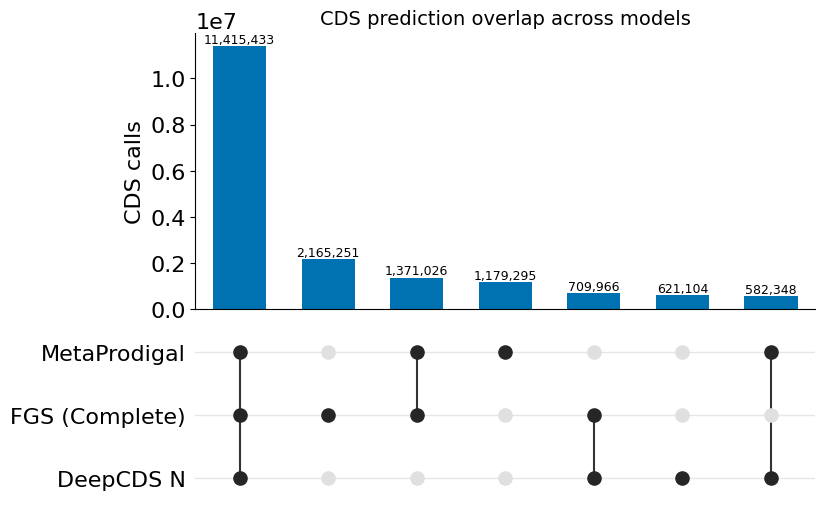

In [10]:
def plot_upset(combo_counts, models, top_n=15, title="CDS prediction overlap across models"):
    """UpSet-style plot: a bar per model-combination (sorted by count, descending) with a
    dot-matrix below showing which models are in each combination. Built from plain
    matplotlib (no extra dependency) so it scales to any number of compared models.

    Args:
        combo_counts: Dict of {frozenset(model_names): count}.
        models: Ordered list of model names to show as dot-matrix rows.
        top_n: Only the top_n largest combinations are plotted (there are 2^len(models)-1
            possible non-empty combinations, most vanishingly small once you compare more
            than 3-4 models).
        title: Plot title.
    """
    sorted_combos = sorted(combo_counts.items(), key=lambda kv: kv[1], reverse=True)[:top_n]
    if not sorted_combos:
        print("No data available.")
        return

    combos = [c for c, _ in sorted_combos]
    counts = [n for _, n in sorted_combos]

    n_combos = len(combos)
    n_models = len(models)

    fig = plt.figure(figsize=(max(8, n_combos * 0.8), 5 + n_models * 0.4))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1 + n_models * 0.35], hspace=0.05)

    ax_bar = fig.add_subplot(gs[0])
    ax_dot = fig.add_subplot(gs[1], sharex=ax_bar)

    x = np.arange(n_combos)
    ax_bar.bar(x, counts, color="#0072B2", width=0.6)
    for xi, c in zip(x, counts):
        ax_bar.text(xi, c, f"{c:,}", ha='center', va='bottom', fontsize=9)
    ax_bar.set_ylabel("CDS calls")
    ax_bar.set_title(title, fontsize=14)
    ax_bar.spines[['top', 'right']].set_visible(False)
    plt.setp(ax_bar.get_xticklabels(), visible=False)
    ax_bar.tick_params(bottom=False)

    for yi in range(n_models):
        ax_dot.axhline(yi, color="0.9", linewidth=1, zorder=0)
    for xi, combo in enumerate(combos):
        present_y = [yi for yi, model in enumerate(models) if model in combo]
        if len(present_y) > 1:
            ax_dot.plot([xi, xi], [min(present_y), max(present_y)], color="0.2", linewidth=1.5, zorder=1)
        for yi, model in enumerate(models):
            filled = model in combo
            ax_dot.scatter([xi], [yi], s=90,
                            color="0.15" if filled else "0.88",
                            zorder=2)

    ax_dot.set_yticks(np.arange(n_models))
    ax_dot.set_yticklabels([model_display_names.get(m, m) for m in models])
    ax_dot.set_xticks(x)
    ax_dot.set_xticklabels([])
    ax_dot.set_xlim(-0.5, n_combos - 0.5)
    ax_dot.set_ylim(-0.5, n_models - 0.5)
    ax_dot.invert_yaxis()
    for spine in ax_dot.spines.values():
        spine.set_visible(False)
    ax_dot.tick_params(left=False, bottom=False)

    plt.tight_layout()
    #plt.savefig("cds_prediction_overlap_upset.svg", dpi=500)
    plt.show()

plot_upset(combo_counts, models_to_compare)

# Full combination table

In [11]:
for combo, count in sorted(combo_counts.items(), key=lambda kv: kv[1], reverse=True):
    label = " + ".join(sorted(model_display_names.get(m, m) for m in combo))
    print(f"{count:>12,}   {label}")

  11,415,433   DeepCDS N + FGS (Complete) + MetaProdigal
   2,165,251   FGS (Complete)
   1,371,026   FGS (Complete) + MetaProdigal
   1,179,295   MetaProdigal
     709,966   DeepCDS N + FGS (Complete)
     621,104   DeepCDS N
     582,348   DeepCDS N + MetaProdigal
